In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading Dataset

In [2]:
df = pd.read_csv('nhtsa_vehicle_safety_recall_intelligence_ultimate.csv')
df.head(5)

,record_id,nhtsa_record_id,recall_campaign_id,manufacturer_campaign_id,vehicle_make,vehicle_model,vehicle_year,vehicle_year_num,vehicle_era,manufacturer_name,...,source_url,scrape_date,dataset_version,record_creation_date,RCL_CMPT_ID,MFR_COMP_NAME,MFR_COMP_DESC,MFR_COMP_PTNO,creation_date_parsed,defect_severity_score
0,835d8908b3a39d,105867,14V400000,14350,OLDSMOBILE,INTRIGUE,1998.0,1998.0,1990s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707.0,000056617000202679000000212,NaN,NaN,NaN,2014-07-07,0.3979
1,1e393b1efc0ea4,105872,14V400000,14350,CHEVROLET,MALIBU CLASSIC,2005.0,2005.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707.0,000056617000204360000000212,NaN,NaN,NaN,2014-07-07,0.3979
2,1ea55f8d43bf01,105885,14V400000,14350,OLDSMOBILE,ALERO,2001.0,2001.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707.0,000056617000202733000000212,NaN,NaN,NaN,2014-07-07,0.3979
3,3588d2734c086b,105883,14V400000,14350,PONTIAC,GRAND AM,2000.0,2000.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707.0,000056617000202623000000212,NaN,NaN,NaN,2014-07-07,0.3979
4,ab8db036507579,105882,14V400000,14350,PONTIAC,GRAND AM,2002.0,2002.0,2000s,General Motors LLC,...,https://static.nhtsa.gov/odi/ffdd/rcl/FLAT_RCL...,2026-04-21,v1.0,20140707.0,000056617000202625000000212,NaN,NaN,NaN,2014-07-07,0.3979


In [3]:
# dimensions
df.shape

(12909, 53)

In [4]:
# columns
for i in df.columns:
  print(i)

record_id
nhtsa_record_id
recall_campaign_id
manufacturer_campaign_id
vehicle_make
vehicle_model
vehicle_year
vehicle_year_num
vehicle_era
manufacturer_name
manufacturer_text
make_origin
recall_type_code
recall_type_label
component_name
component_category
recall_initiation_date
recall_date_parsed
report_received_date
owner_notification_date
notification_date_parsed
manufacture_date_begin
manufacture_date_end
recall_year
recall_month
recall_quarter
recall_age_days
days_to_owner_notification
potential_units_affected
units_affected_num
recall_scale
defect_summary
consequence_summary
corrective_action
notes
defect_severity
fire_risk_flag
manufacturer_recall_count
is_repeat_manufacturer
recall_risk_score
risk_tier
influenced_by
data_source
source_url
scrape_date
dataset_version
record_creation_date
RCL_CMPT_ID
MFR_COMP_NAME
MFR_COMP_DESC
MFR_COMP_PTNO
creation_date_parsed
defect_severity_score


In [5]:
# current goal: predict defect severity score

# EDA

In [27]:
# checking column types
for i in df.columns:
  print(f"\n{i}")
  types_in_col = df[i].apply(type).value_counts()
  for dtype, count in types_in_col.items():
    print(f"{dtype.__name__}: {count} values")
  if df[i].isna().sum() > 0:
    print(f"missing: {df[i].isna().sum()}")


record_id
str: 12909 values

nhtsa_record_id
int: 12909 values

recall_campaign_id
str: 12909 values

manufacturer_campaign_id
str: 9152 values
float: 3757 values
missing: 3757

vehicle_make
str: 12909 values

vehicle_model
str: 12909 values

vehicle_year
float: 12909 values
missing: 272

vehicle_year_num
float: 12909 values
missing: 272

vehicle_era
str: 12637 values
float: 272 values
missing: 272

manufacturer_name
str: 12909 values

manufacturer_text
str: 12909 values

make_origin
str: 12909 values

recall_type_code
str: 12909 values

recall_type_label
str: 12909 values

component_name
str: 12909 values

component_category
str: 12909 values

recall_initiation_date
int: 12909 values

recall_date_parsed
str: 12909 values

report_received_date
str: 12909 values

owner_notification_date
float: 12909 values
missing: 220

notification_date_parsed
str: 12689 values
float: 220 values
missing: 220

manufacture_date_begin
float: 12909 values
missing: 6987

manufacture_date_end
float: 12909 v

## Numerical Columns

In [7]:
numerical = df.select_dtypes(include='number').columns.tolist()
numerical

['nhtsa_record_id',
 'vehicle_year',
 'vehicle_year_num',
 'recall_initiation_date',
 'owner_notification_date',
 'manufacture_date_begin',
 'manufacture_date_end',
 'recall_year',
 'recall_month',
 'recall_quarter',
 'recall_age_days',
 'days_to_owner_notification',
 'potential_units_affected',
 'units_affected_num',
 'fire_risk_flag',
 'manufacturer_recall_count',
 'is_repeat_manufacturer',
 'recall_risk_score',
 'record_creation_date',
 'defect_severity_score']

In [32]:
# looking for finite categorical cols
categorical = df.select_dtypes(include='object').columns.tolist()
for col in categorical:
  print(f"\nColumn: {col}")
  print(f"Unique values count: {df[col].nunique()}")
  # print("Top 5 unique values and their counts:")
  # print(df[col].value_counts().head())


Column: record_id
Unique values count: 12909

Column: recall_campaign_id
Unique values count: 935

Column: manufacturer_campaign_id
Unique values count: 719

Column: vehicle_make
Unique values count: 218

Column: vehicle_model
Unique values count: 2051

Column: vehicle_era
Unique values count: 5

Column: manufacturer_name
Unique values count: 195

Column: manufacturer_text
Unique values count: 157

Column: make_origin
Unique values count: 7

Column: recall_type_code
Unique values count: 4

Column: recall_type_label
Unique values count: 4

Column: component_name
Unique values count: 176

Column: component_category
Unique values count: 12

Column: recall_date_parsed
Unique values count: 781

Column: report_received_date
Unique values count: 2

Column: notification_date_parsed
Unique values count: 775

Column: recall_scale
Unique values count: 4

Column: defect_summary
Unique values count: 933

Column: consequence_summary
Unique values count: 652

Column: corrective_action
Unique values 

In [35]:
# cols where I can exploit categories

finite_categorical = []

for col in categorical:
  if df[col].nunique() < 50:
    print(f"\n{col}")
    print(f"Unique values count: {df[col].nunique()}")
    finite_categorical.append(col)


vehicle_era
Unique values count: 5

make_origin
Unique values count: 7

recall_type_code
Unique values count: 4

recall_type_label
Unique values count: 4

component_category
Unique values count: 12

report_received_date
Unique values count: 2

recall_scale
Unique values count: 4

defect_severity
Unique values count: 4

risk_tier
Unique values count: 3

influenced_by
Unique values count: 3

data_source
Unique values count: 1

source_url
Unique values count: 1

scrape_date
Unique values count: 1

dataset_version
Unique values count: 1


In [ ]:
# categorical distribution conclusions:
  # vehicle_era: mostly 2010s, less and less as more in the past
    # strategy: is_2010s col
  # make_origin: mostly US_domestic
    # make is_US_domestic col
    # make is_other col, other is next biggest
  # recall_type_code
    # overwhelmingly V
    # some E
    # minimal others (T or C)
  # recall_type_label
    # same as above but words instead
  # component category: good amount of categories
  # report_received_date: binary but all No, no Yes
  # recall_scale: 4 level ordinal
    # ordinal encode
    # Medium Large Massive Mega
  # defect_severity: 4 level ordinal
    # pretty uniform
    # ordinal encode
    # LOW MEDIUM HIGH CRITICAL
  # risk_tier
    # 3 level ordinal
    # ordinal encode
    # LOW MEDIUM HIGH
    # most lows then med then high
  # influenced_by
    # 3 level ordinal
    # ordinal encode
    # mostly MFR, some ODI, no OVSC
  # data_source
    # one value, NHTSA ODI Flat File
  # source_url
    # one value, url
  # scrape_date
    # all one day, 2026-04-21
  # dataset_version
    # all one version, v1.0



vehicle_era


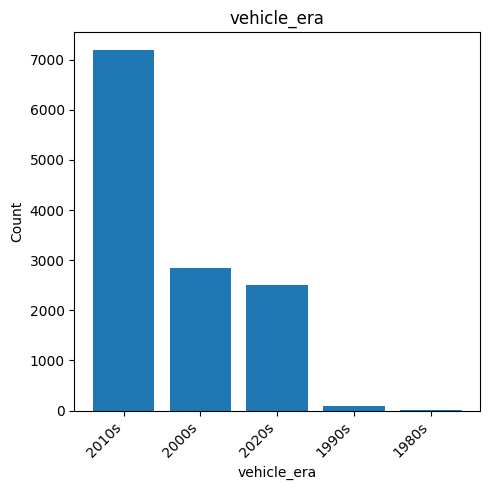


make_origin


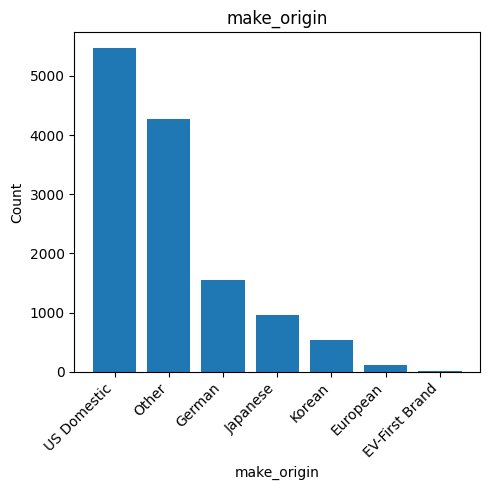


recall_type_code


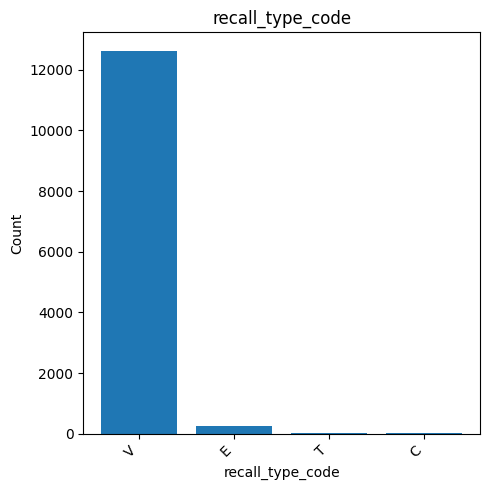


recall_type_label


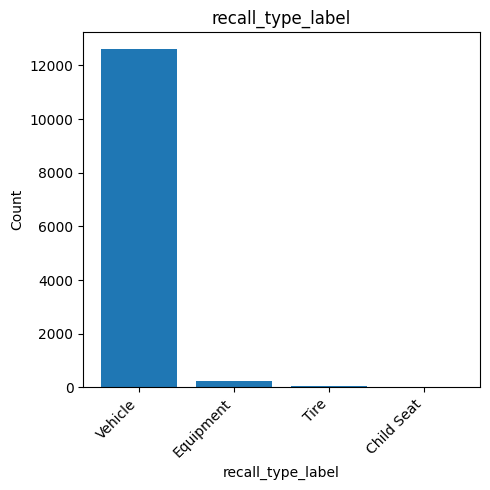


component_category


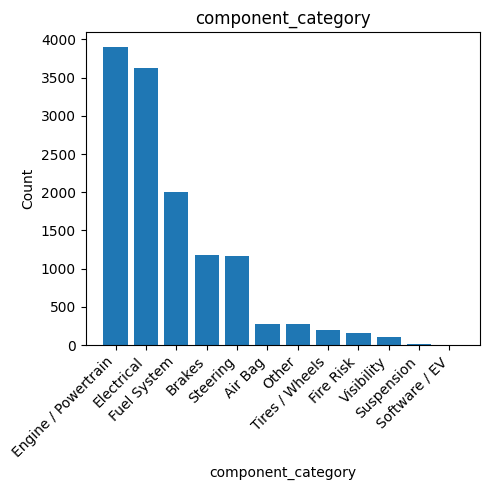


report_received_date


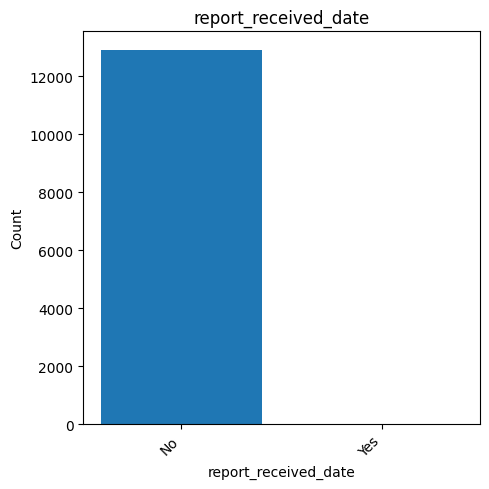


recall_scale


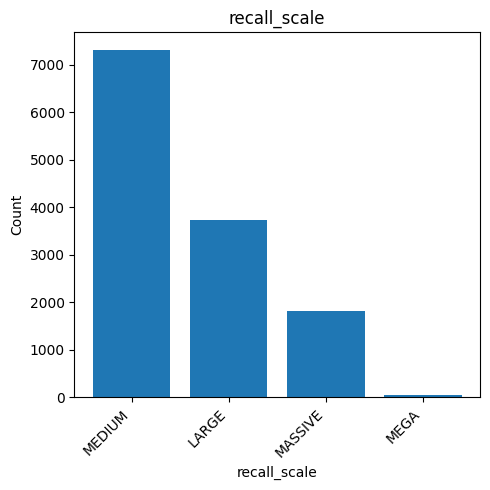


defect_severity


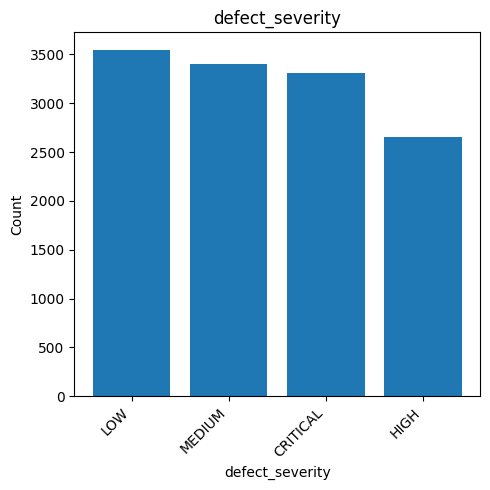


risk_tier


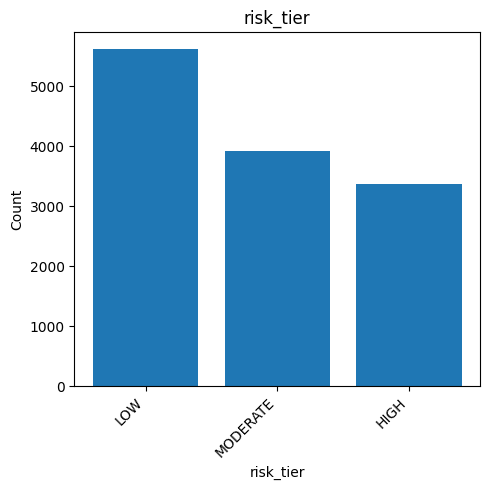


influenced_by


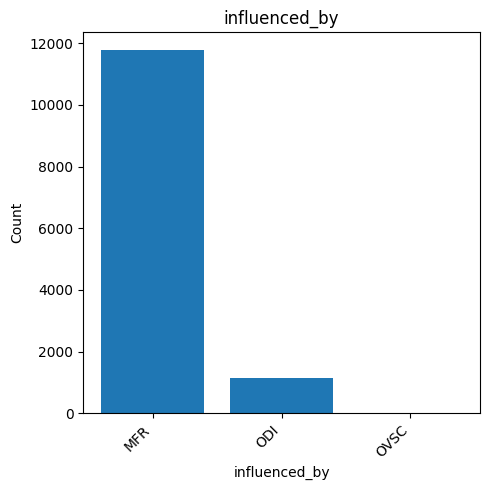


data_source


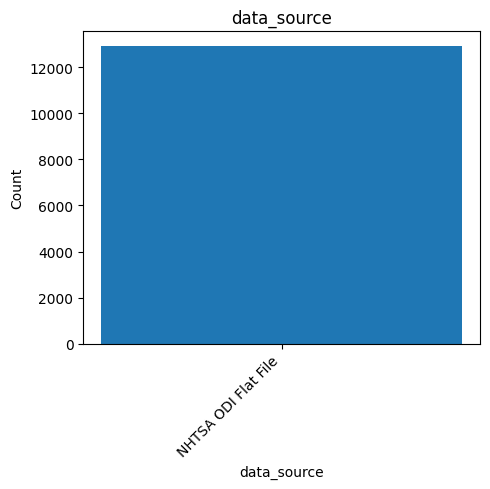


source_url


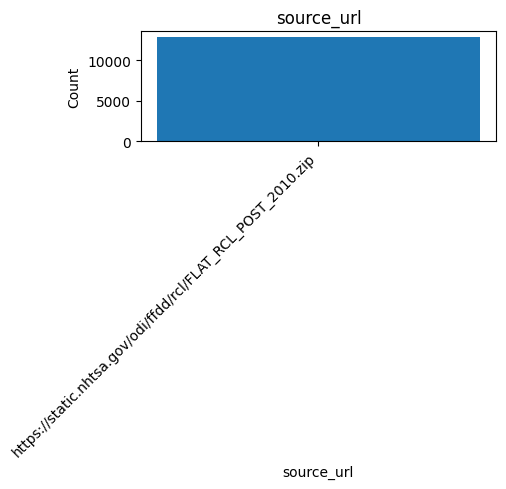


scrape_date


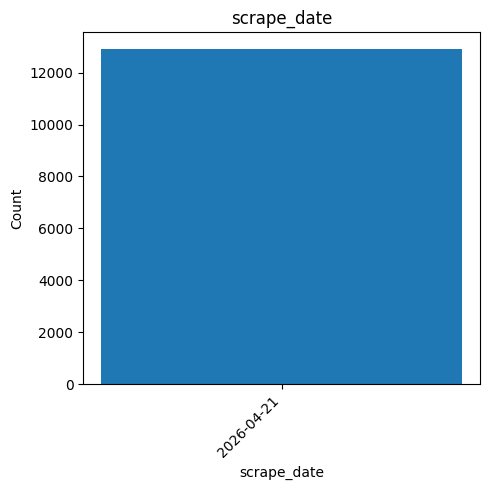


dataset_version


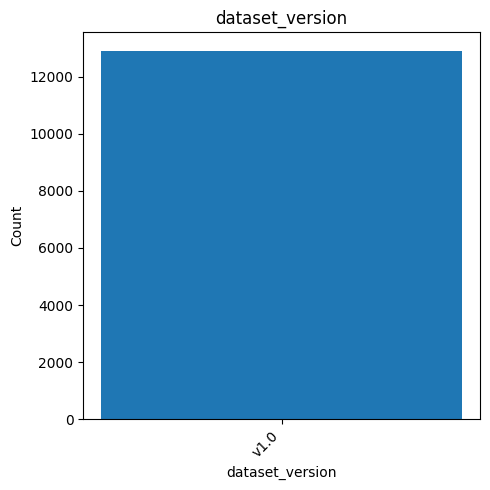

In [41]:
# plotting categorical
for col in finite_categorical:
  print(f"\n{col}")
  counts = df[col].value_counts()
  plt.figure(figsize=(5, 5))
  plt.bar(counts.index.astype(str), counts.values)
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.title(f"{col}")
  plt.xticks(rotation=45, ha='right')
  plt.tight_layout()
  plt.show()

In [ ]:
# Numerical distributions:
  # nhtsa_record_id: unimodal, heavily right skewed
  # vehicle_year: unimodal, pretty normal, minimally left skewed
  # vehicle_year_num: same as ^?
  # recall_initiation_date: unimodal, centered, ROUGH normal shape but consistent distribution
  # owner_notification_date: unimodal, very similar to ^
  # manufacture_date_begin: unimodal, almost all on right end extreme, seemingly minimal difference between bins (0.02
  # manufacture_date_end: similar/same as ^
  # recall_year: unimodal, rough normal distribution, consistent on both sides
  # recall month: unimodal but not normal at all, mode at far right and pretty uniform elsewhere
  # recall_quarter: mostly 4 but each quarter has good count
  # recall_age_days: unimodal, roughly normal shape
  # days_to_owner: unimodal, not normal, mode far left, entirely skewed right, minimal far right outliers
  # potential_units_affected: ^ similar, same conclusions but different
  # units_affected_num: ^ similar, same conclusions but different
  # fire risk flag: from 0.0 to 1.0, two bins, one (0) overwhelming, other (1.0) minimal but there
  # manufacturer_recall_count: unimodal, high mode far left, skewed and outliers
  # is_repeat_manufacturer: seems to all be in 1.0 bin
  # recall_risk_score: unique shape, 3 L trend blocks, pretty uniform
  # record_creation_date: unimodal, roughly normal
  # defect_severity_score: roughly normal, but more data on right side than left

In [ ]:
# to inspect more:
  # manufacture_date_begin and manufacture_date_end: check what kind of objects, convert to datetime
  # recall_month: categorical 1-12
  # recall_quarter: categorical 1.0-4.0

nhtsa_record_id


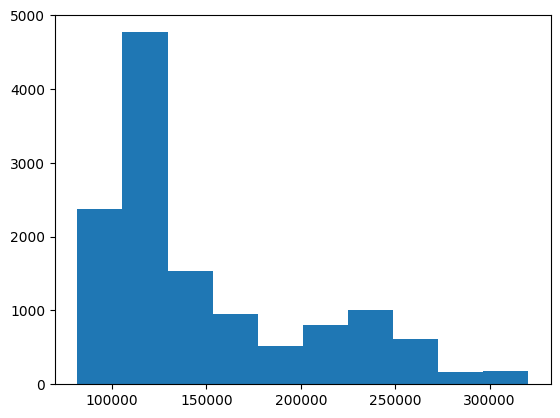

vehicle_year


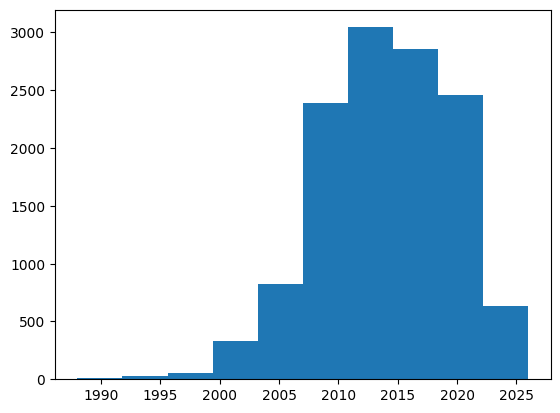

vehicle_year_num


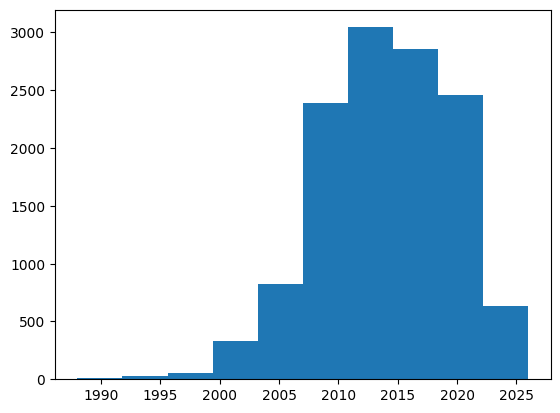

recall_initiation_date


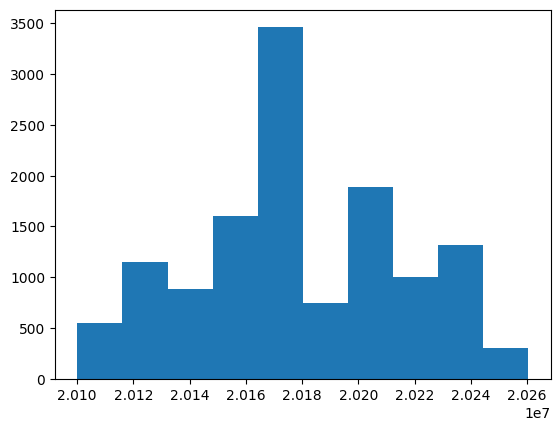

owner_notification_date


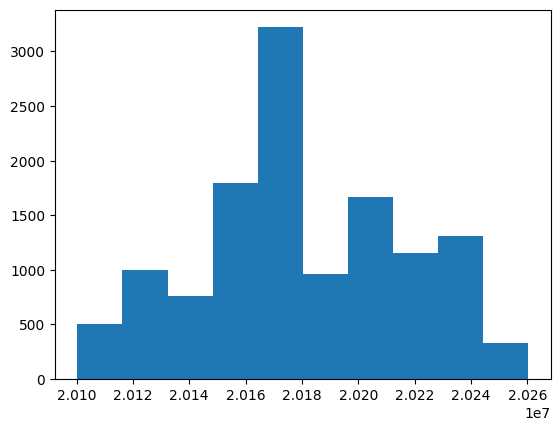

manufacture_date_begin


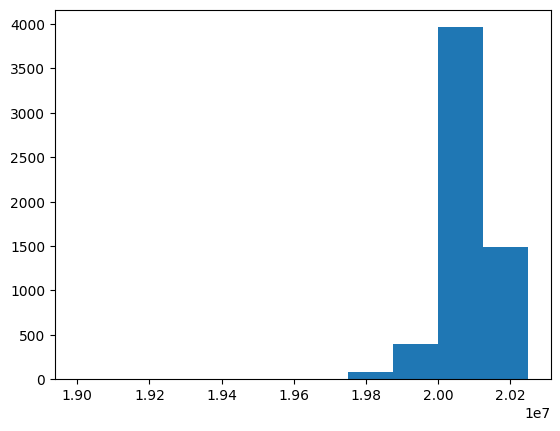

manufacture_date_end


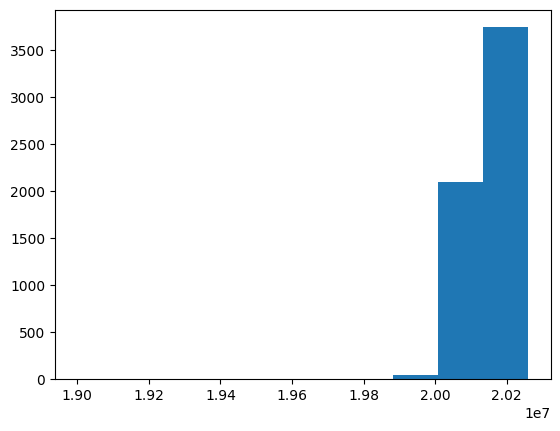

recall_year


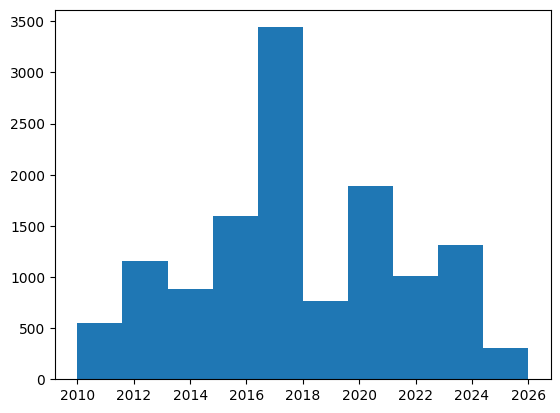

recall_month


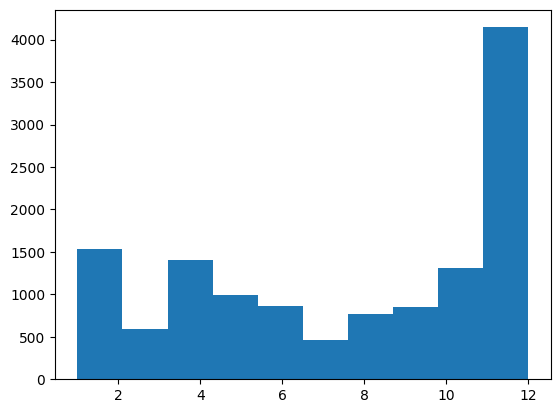

recall_quarter


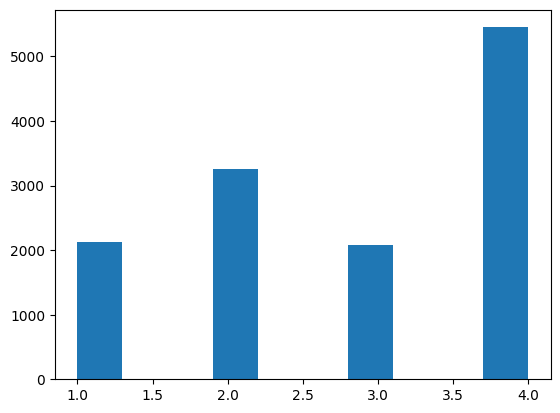

recall_age_days


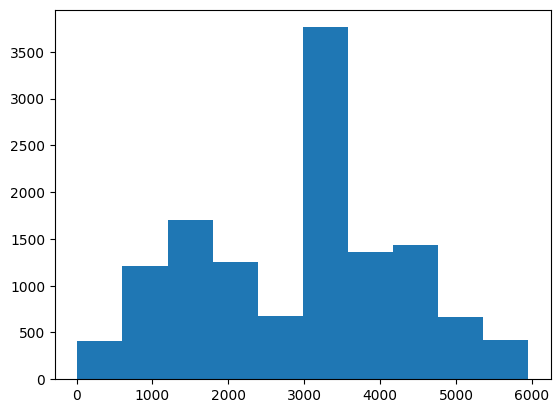

days_to_owner_notification


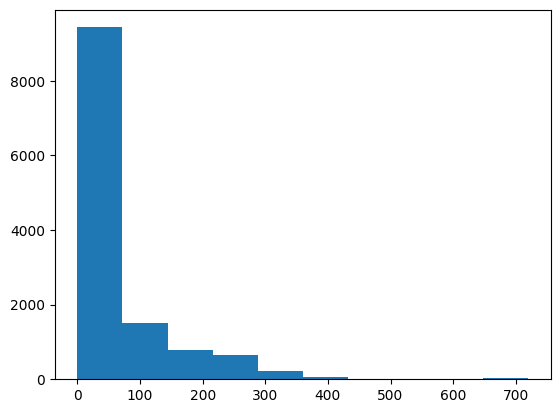

potential_units_affected


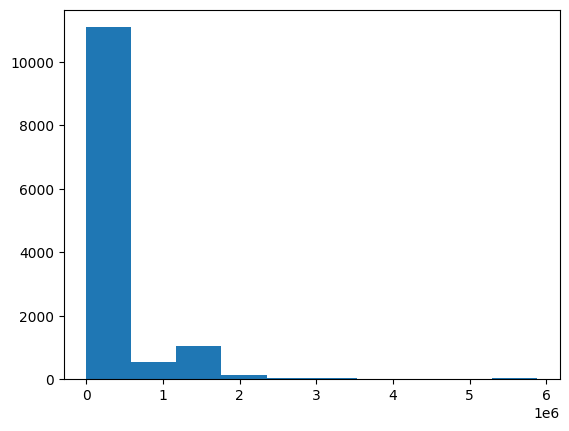

units_affected_num


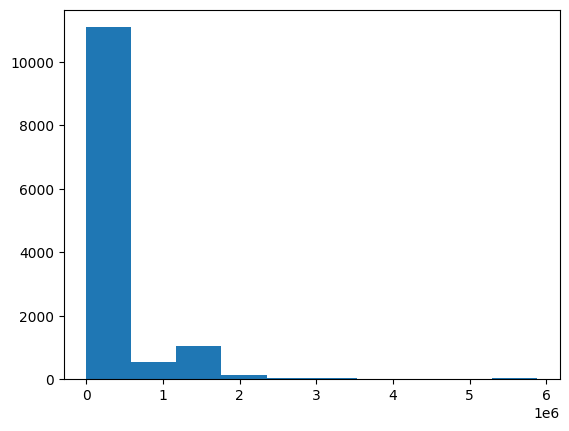

fire_risk_flag


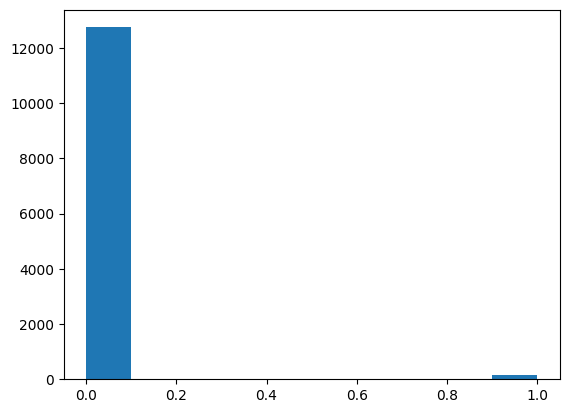

manufacturer_recall_count


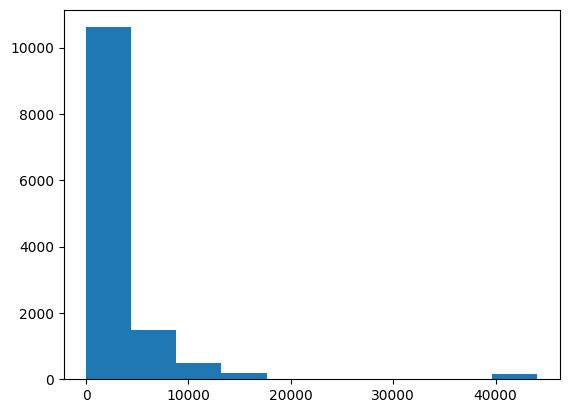

is_repeat_manufacturer


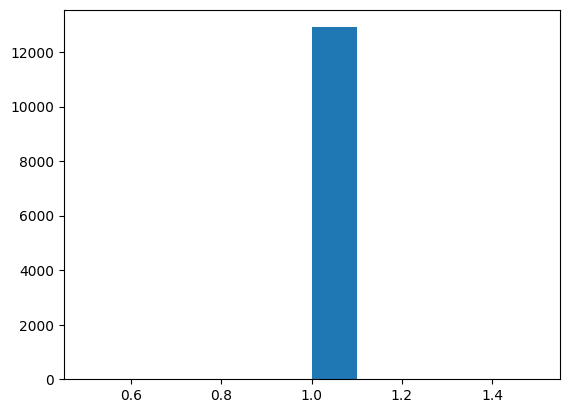

recall_risk_score


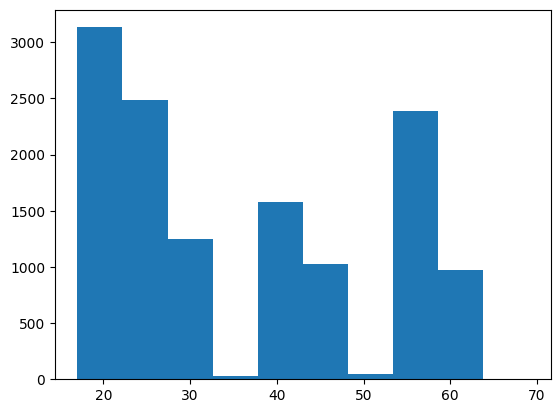

record_creation_date


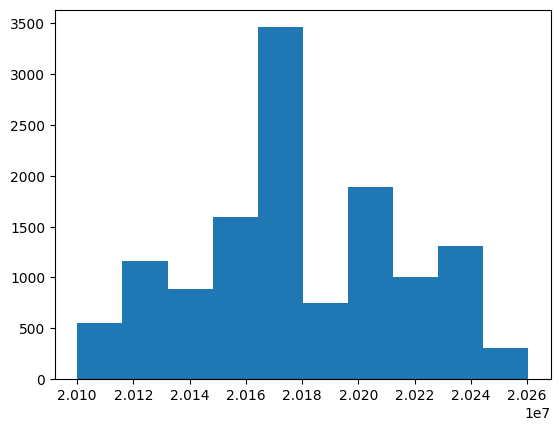

defect_severity_score


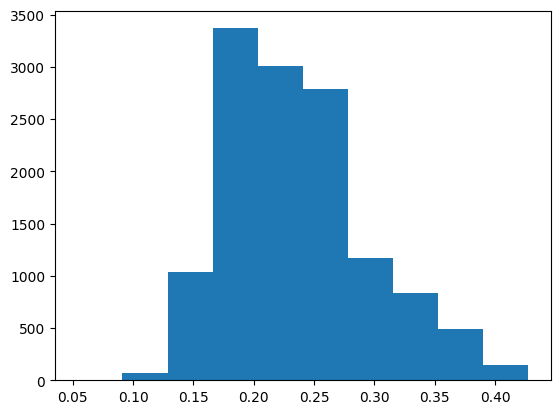

In [28]:
# inspecting col distributions
for col in numerical:
  print(f"{col}")
  plt.hist(df[col])
  plt.show()

# Missingness

In [24]:
# getting cols with missing vals

cols_with_nan = []

for i in df.columns:
  if df[i].isna().sum() > 0:
    cols_with_nan.append(i)

for i in cols_with_nan:
  print(i)

manufacturer_campaign_id
vehicle_year
vehicle_year_num
vehicle_era
owner_notification_date
notification_date_parsed
manufacture_date_begin
manufacture_date_end
days_to_owner_notification
recall_scale
defect_summary
consequence_summary
corrective_action
notes
defect_severity
fire_risk_flag
manufacturer_recall_count
is_repeat_manufacturer
recall_risk_score
risk_tier
influenced_by
data_source
source_url
scrape_date
dataset_version
record_creation_date
RCL_CMPT_ID
MFR_COMP_NAME
MFR_COMP_DESC
MFR_COMP_PTNO
creation_date_parsed
defect_severity_score
